In [2]:
# 2.4.1 Импорты, seed и устройство
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, SubsetRandomSampler
import numpy as np
import matplotlib.pyplot as plt
from torchvision.models import resnet18, ResNet18_Weights
import os
import json
import pandas as pd
from PIL import Image
import random
from sklearn.model_selection import train_test_split

# Фиксация seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


In [4]:
# 2.4.2 Данные и DataLoader для CIFAR10 (Часть A)

from sklearn.model_selection import train_test_split

# Преобразования для CIFAR10 (32x32 изображения)
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616])
])

transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616])
])

# Загрузка CIFAR10
train_dataset_full = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_base
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_base
)

# Разделение train на train/val (80/20)
train_indices, val_indices = train_test_split(
    list(range(len(train_dataset_full))), test_size=0.2, random_state=42
)

# DataLoader для C1 (без аугментаций)
train_loader_base = DataLoader(
    torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_base),
    batch_size=64, sampler=SubsetRandomSampler(train_indices), num_workers=2
)

val_loader_base = DataLoader(
    torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_base),
    batch_size=64, sampler=SubsetRandomSampler(val_indices), num_workers=2
)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

# DataLoader для C2 (с аугментациями)
train_loader_aug = DataLoader(
    torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_aug),
    batch_size=64, sampler=SubsetRandomSampler(train_indices), num_workers=2
)

# Sanity-check
print(f"Train samples: {len(train_indices)}, Val samples: {len(val_indices)}, Test samples: {len(test_dataset)}")
images, labels = next(iter(train_loader_base))
print(f"Batch shape: {images.shape}, Labels shape: {labels.shape}")
print(f"Classes: {train_dataset_full.classes}")

100.0%
c:\Users\petr\Desktop\ИИИ\AiMirea25\homeworks\HW10-11\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train samples: 40000, Val samples: 10000, Test samples: 10000
Batch shape: torch.Size([64, 3, 32, 32]), Labels shape: torch.Size([64])
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


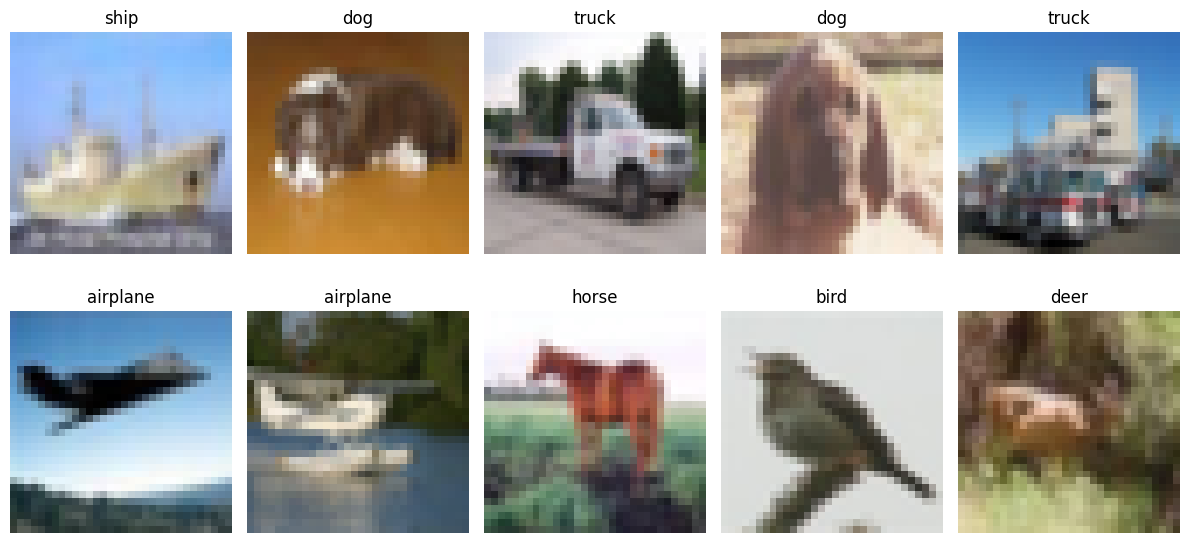

In [6]:
# Визуализация sanity-check
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).numpy()
    img = img * np.array([0.2470, 0.2435, 0.2616]) + np.array([0.4914, 0.4822, 0.4465])
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(train_dataset_full.classes[labels[i]])
    ax.axis('off')
plt.tight_layout()
plt.savefig('artifacts/figures/sanity_check.png')
plt.show()

In [7]:
# 2.4.3 Базовые функции обучения и оценки

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """Обучение одной эпохи"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, val_loader, criterion, device):
    """Оценка модели"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def train_model(model, train_loader, val_loader, epochs, lr, device):
    """Полный цикл обучения"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    best_val_acc = 0.0
    
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    return history, best_val_acc, best_model_state

In [8]:
# 3.1 Эксперимент C1: простая CNN без аугментаций

class SimpleCNN(nn.Module):
    """Простая CNN для CIFAR10 (32x32 изображения)"""
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 32 -> 16
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 16 -> 8
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 8 -> 4
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Создание модели
model_c1 = SimpleCNN(num_classes=10).to(device)
print(f"Model C1 parameters: {sum(p.numel() for p in model_c1.parameters())}")

# Обучение
history_c1, best_val_acc_c1, best_model_c1 = train_model(
    model_c1, train_loader_base, val_loader_base, 
    epochs=10, lr=0.001, device=device
)

print(f"C1 best val accuracy: {best_val_acc_c1:.4f}")

Model C1 parameters: 620362
Epoch 1/10 | Train Loss: 1.5060 | Train Acc: 0.4490 | Val Loss: 1.1540 | Val Acc: 0.5887
Epoch 2/10 | Train Loss: 1.0986 | Train Acc: 0.6071 | Val Loss: 0.9498 | Val Acc: 0.6606
Epoch 3/10 | Train Loss: 0.9223 | Train Acc: 0.6757 | Val Loss: 0.8256 | Val Acc: 0.7074
Epoch 4/10 | Train Loss: 0.8060 | Train Acc: 0.7153 | Val Loss: 0.7745 | Val Acc: 0.7252
Epoch 5/10 | Train Loss: 0.7154 | Train Acc: 0.7489 | Val Loss: 0.7446 | Val Acc: 0.7425
Epoch 6/10 | Train Loss: 0.6428 | Train Acc: 0.7751 | Val Loss: 0.7259 | Val Acc: 0.7515
Epoch 7/10 | Train Loss: 0.5828 | Train Acc: 0.7953 | Val Loss: 0.7165 | Val Acc: 0.7511
Epoch 8/10 | Train Loss: 0.5328 | Train Acc: 0.8121 | Val Loss: 0.6897 | Val Acc: 0.7644
Epoch 9/10 | Train Loss: 0.4793 | Train Acc: 0.8286 | Val Loss: 0.7109 | Val Acc: 0.7613
Epoch 10/10 | Train Loss: 0.4369 | Train Acc: 0.8431 | Val Loss: 0.7325 | Val Acc: 0.7653
C1 best val accuracy: 0.7653


In [9]:
# 3.1 Эксперимент C2: простая CNN с аугментациями

# Используем ту же архитектуру SimpleCNN, что и в C1
model_c2 = SimpleCNN(num_classes=10).to(device)
print(f"Model C2 parameters: {sum(p.numel() for p in model_c2.parameters())}")

# Обучение с аугментированными данными
history_c2, best_val_acc_c2, best_model_c2 = train_model(
    model_c2, train_loader_aug, val_loader_base, 
    epochs=10, lr=0.001, device=device
)

print(f"C2 best val accuracy: {best_val_acc_c2:.4f}")

Model C2 parameters: 620362
Epoch 1/10 | Train Loss: 1.6007 | Train Acc: 0.4153 | Val Loss: 1.2130 | Val Acc: 0.5618
Epoch 2/10 | Train Loss: 1.2420 | Train Acc: 0.5565 | Val Loss: 1.0511 | Val Acc: 0.6296
Epoch 3/10 | Train Loss: 1.0846 | Train Acc: 0.6176 | Val Loss: 0.9306 | Val Acc: 0.6761
Epoch 4/10 | Train Loss: 0.9875 | Train Acc: 0.6541 | Val Loss: 0.8484 | Val Acc: 0.7011
Epoch 5/10 | Train Loss: 0.9129 | Train Acc: 0.6829 | Val Loss: 0.8117 | Val Acc: 0.7105
Epoch 6/10 | Train Loss: 0.8569 | Train Acc: 0.6996 | Val Loss: 0.7832 | Val Acc: 0.7178
Epoch 7/10 | Train Loss: 0.8181 | Train Acc: 0.7138 | Val Loss: 0.7395 | Val Acc: 0.7426
Epoch 8/10 | Train Loss: 0.7845 | Train Acc: 0.7271 | Val Loss: 0.7319 | Val Acc: 0.7483
Epoch 9/10 | Train Loss: 0.7558 | Train Acc: 0.7365 | Val Loss: 0.6817 | Val Acc: 0.7639
Epoch 10/10 | Train Loss: 0.7257 | Train Acc: 0.7489 | Val Loss: 0.6700 | Val Acc: 0.7658
C2 best val accuracy: 0.7658


In [10]:
# 3.1 Эксперимент C3: ResNet18 с pretrained weights, замороженный backbone

from torchvision.models import resnet18, ResNet18_Weights

# Загрузка предобученной модели
weights = ResNet18_Weights.IMAGENET1K_V1
model_c3 = resnet18(weights=weights)

# Заморозка всех слоев
for param in model_c3.parameters():
    param.requires_grad = False

# Замена классификационной головы для CIFAR10 (10 классов)
num_features = model_c3.fc.in_features
model_c3.fc = nn.Linear(num_features, 10)

# Перенос на устройство
model_c3 = model_c3.to(device)

print(f"Model C3: ResNet18 with frozen backbone")
print(f"Trainable parameters: {sum(p.numel() for p in model_c3.parameters() if p.requires_grad)}")

# Обучение только головы
history_c3, best_val_acc_c3, best_model_c3 = train_model(
    model_c3, train_loader_base, val_loader_base, 
    epochs=10, lr=0.001, device=device
)

print(f"C3 best val accuracy: {best_val_acc_c3:.4f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\petr/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Model C3: ResNet18 with frozen backbone
Trainable parameters: 5130
Epoch 1/10 | Train Loss: 1.7594 | Train Acc: 0.3860 | Val Loss: 1.5937 | Val Acc: 0.4500
Epoch 2/10 | Train Loss: 1.6117 | Train Acc: 0.4388 | Val Loss: 1.6026 | Val Acc: 0.4443
Epoch 3/10 | Train Loss: 1.5880 | Train Acc: 0.4468 | Val Loss: 1.5826 | Val Acc: 0.4583
Epoch 4/10 | Train Loss: 1.5832 | Train Acc: 0.4465 | Val Loss: 1.5570 | Val Acc: 0.4627
Epoch 5/10 | Train Loss: 1.5722 | Train Acc: 0.4533 | Val Loss: 1.5980 | Val Acc: 0.4510
Epoch 6/10 | Train Loss: 1.5638 | Train Acc: 0.4538 | Val Loss: 1.5941 | Val Acc: 0.4562
Epoch 7/10 | Train Loss: 1.5622 | Train Acc: 0.4548 | Val Loss: 1.5565 | Val Acc: 0.4636
Epoch 8/10 | Train Loss: 1.5610 | Train Acc: 0.4535 | Val Loss: 1.5753 | Val Acc: 0.4573
Epoch 9/10 | Train Loss: 1.5747 | Train Acc: 0.4495 | Val Loss: 1.5581 | Val Acc: 0.4624
Epoch 10/10 | Train Loss: 1.5591 | Train Acc: 0.4559 | Val Loss: 1.5687 | Val Acc: 0.4614
C3 best val accuracy: 0.4636


In [11]:
# 3.1 Эксперимент C4: ResNet18 с fine-tuning (разморожены последние слои)

from torchvision.models import resnet18, ResNet18_Weights

# Загрузка предобученной модели
weights = ResNet18_Weights.IMAGENET1K_V1
model_c4 = resnet18(weights=weights)

# Заморозка всех слоев
for param in model_c4.parameters():
    param.requires_grad = False

# Разморозка последнего блока (layer4) и классификатора
for param in model_c4.layer4.parameters():
    param.requires_grad = True

# Замена классификационной головы
num_features = model_c4.fc.in_features
model_c4.fc = nn.Linear(num_features, 10)
# Голова обучается (requires_grad=True по умолчанию)

# Перенос на устройство
model_c4 = model_c4.to(device)

print(f"Model C4: ResNet18 with layer4 + fc unfrozen")
print(f"Trainable parameters: {sum(p.numel() for p in model_c4.parameters() if p.requires_grad)}")

# Обучение с меньшей learning rate для fine-tuning
history_c4, best_val_acc_c4, best_model_c4 = train_model(
    model_c4, train_loader_base, val_loader_base, 
    epochs=10, lr=0.0005, device=device
)

print(f"C4 best val accuracy: {best_val_acc_c4:.4f}")

Model C4: ResNet18 with layer4 + fc unfrozen
Trainable parameters: 8398858
Epoch 1/10 | Train Loss: 1.1803 | Train Acc: 0.5898 | Val Loss: 0.9395 | Val Acc: 0.6763
Epoch 2/10 | Train Loss: 0.8336 | Train Acc: 0.7064 | Val Loss: 0.8839 | Val Acc: 0.6963
Epoch 3/10 | Train Loss: 0.6802 | Train Acc: 0.7605 | Val Loss: 0.8991 | Val Acc: 0.7010
Epoch 4/10 | Train Loss: 0.5575 | Train Acc: 0.8025 | Val Loss: 0.9229 | Val Acc: 0.7023
Epoch 5/10 | Train Loss: 0.4566 | Train Acc: 0.8385 | Val Loss: 0.9725 | Val Acc: 0.7046
Epoch 6/10 | Train Loss: 0.3777 | Train Acc: 0.8639 | Val Loss: 1.0046 | Val Acc: 0.7009
Epoch 7/10 | Train Loss: 0.3187 | Train Acc: 0.8854 | Val Loss: 1.1324 | Val Acc: 0.6917
Epoch 8/10 | Train Loss: 0.2729 | Train Acc: 0.9017 | Val Loss: 1.1867 | Val Acc: 0.7002
Epoch 9/10 | Train Loss: 0.2383 | Train Acc: 0.9152 | Val Loss: 1.2406 | Val Acc: 0.6969
Epoch 10/10 | Train Loss: 0.2083 | Train Acc: 0.9263 | Val Loss: 1.3325 | Val Acc: 0.6917
C4 best val accuracy: 0.7046


In [12]:
# 3.1 Выбор лучшей модели по val_accuracy

results = {
    'C1': best_val_acc_c1,
    'C2': best_val_acc_c2,
    'C3': best_val_acc_c3,
    'C4': best_val_acc_c4
}

best_exp = max(results, key=results.get)
best_val_acc = results[best_exp]

print(f"\n=== Comparison ===")
for exp, acc in results.items():
    print(f"{exp}: val_acc = {acc:.4f}")
print(f"\nBest experiment: {best_exp} with val_acc = {best_val_acc:.4f}")

# Сохранение лучшей модели
if best_exp == 'C1':
    best_model_state = best_model_c1
    best_model = SimpleCNN(num_classes=10)
elif best_exp == 'C2':
    best_model_state = best_model_c2
    best_model = SimpleCNN(num_classes=10)
elif best_exp == 'C3':
    best_model_state = best_model_c3
    best_model = resnet18()
    best_model.fc = nn.Linear(512, 10)
elif best_exp == 'C4':
    best_model_state = best_model_c4
    best_model = resnet18()
    best_model.fc = nn.Linear(512, 10)

# Загрузка весов лучшей модели
best_model.load_state_dict(best_model_state)
best_model = best_model.to(device)

# Финальная оценка на test
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"\nBest model ({best_exp}) test accuracy: {test_acc:.4f}")


=== Comparison ===
C1: val_acc = 0.7653
C2: val_acc = 0.7658
C3: val_acc = 0.4636
C4: val_acc = 0.7046

Best experiment: C2 with val_acc = 0.7658

Best model (C2) test accuracy: 0.7617


In [14]:
# 4.2 Сохранение best_classifier.pt
# Сохраняем веса лучшей модели
torch.save(best_model_state, 'artifacts/best_classifier.pt')
print("best_classifier.pt saved")

best_classifier.pt saved


In [15]:
# 4.3 Сохранение best_classifier_config.json
config = {
    'dataset': 'CIFAR10',
    'num_classes': 10,
    'best_experiment': best_exp,
    'best_val_accuracy': float(best_val_acc),
    'test_accuracy': float(test_acc),
    'seed': 42,
    'epochs': 10,
    'learning_rate': 0.001 if best_exp in ['C1', 'C2', 'C3'] else 0.0005,
    'optimizer': 'Adam',
    'loss_function': 'CrossEntropyLoss'
}

# Добавляем информацию об архитектуре
if best_exp in ['C1', 'C2']:
    config['architecture'] = 'SimpleCNN'
    config['model_params'] = {
        'conv_layers': [32, 64, 128],
        'fc_layers': [256, 10],
        'dropout': 0.5
    }
else:
    config['architecture'] = 'ResNet18'
    if best_exp == 'C3':
        config['training_strategy'] = 'head_only'
        config['frozen_layers'] = 'all_except_fc'
    else:
        config['training_strategy'] = 'finetune'
        config['unfrozen_layers'] = 'layer4_and_fc'

with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(config, f, indent=4)
print("best_classifier_config.json saved")

best_classifier_config.json saved


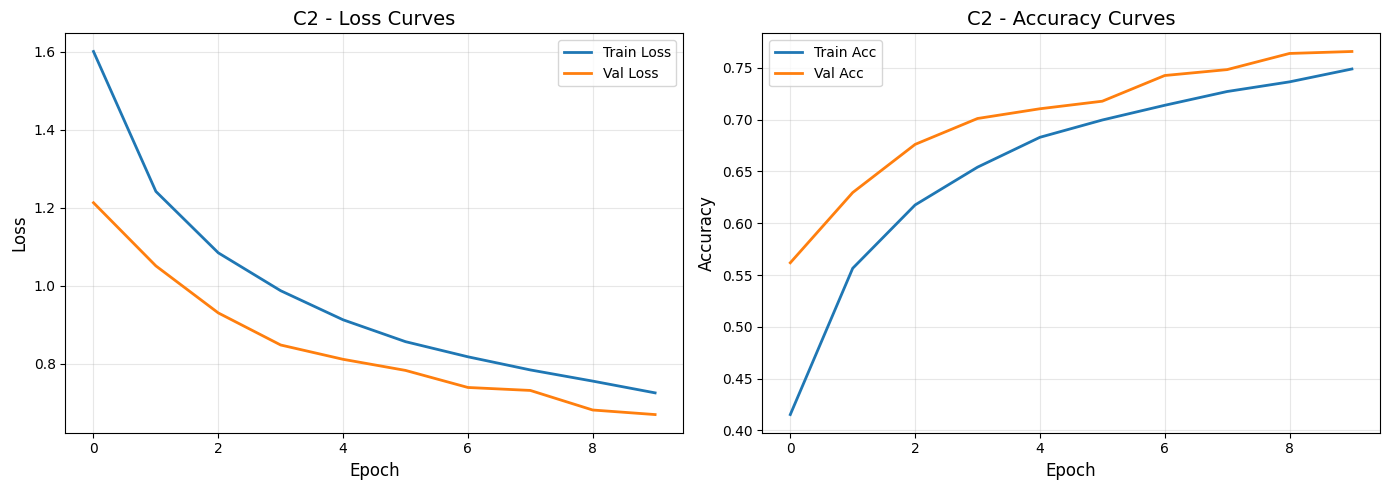

classification_curves_best.png saved


In [16]:
# 4.4 График train/val loss и accuracy для лучшей модели
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Выбор истории лучшей модели
if best_exp == 'C1':
    history = history_c1
elif best_exp == 'C2':
    history = history_c2
elif best_exp == 'C3':
    history = history_c3
else:
    history = history_c4

# График loss
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title(f'{best_exp} - Loss Curves', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# График accuracy
axes[1].plot(history['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title(f'{best_exp} - Accuracy Curves', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/classification_curves_best.png', dpi=150)
plt.show()
print("classification_curves_best.png saved")

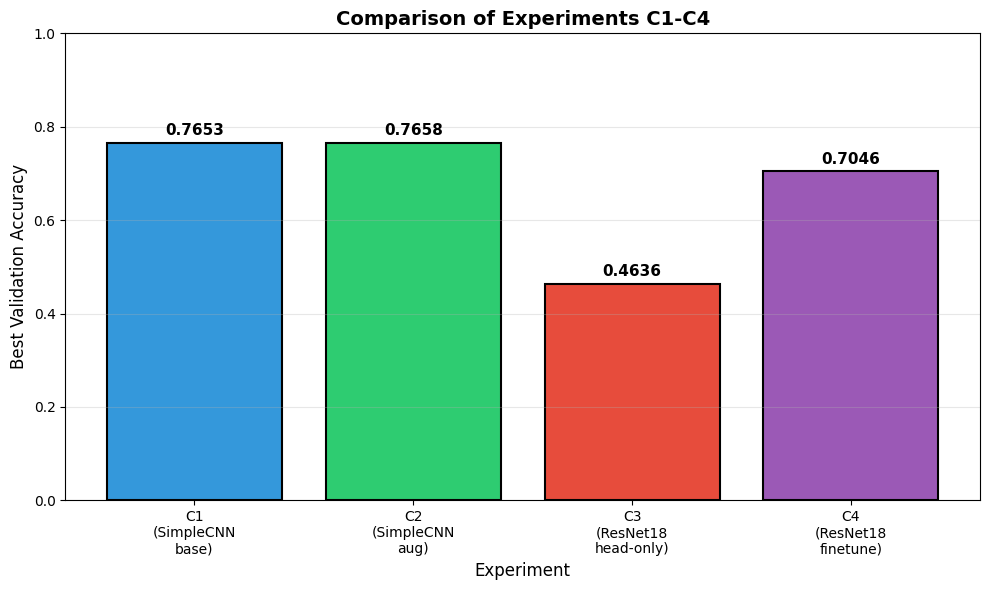

classification_compare.png saved


In [17]:
# 4.5 Сравнение C1-C4 (bar plot)
fig, ax = plt.subplots(figsize=(10, 6))

experiments = ['C1\n(SimpleCNN\nbase)', 'C2\n(SimpleCNN\naug)', 'C3\n(ResNet18\nhead-only)', 'C4\n(ResNet18\nfinetune)']
val_accs = [best_val_acc_c1, best_val_acc_c2, best_val_acc_c3, best_val_acc_c4]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

bars = ax.bar(experiments, val_accs, color=colors, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Experiment', fontsize=12)
ax.set_ylabel('Best Validation Accuracy', fontsize=12)
ax.set_title('Comparison of Experiments C1-C4', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

# Добавление значений на столбцы
for bar, val in zip(bars, val_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('artifacts/figures/classification_compare.png', dpi=150)
plt.show()
print("classification_compare.png saved")

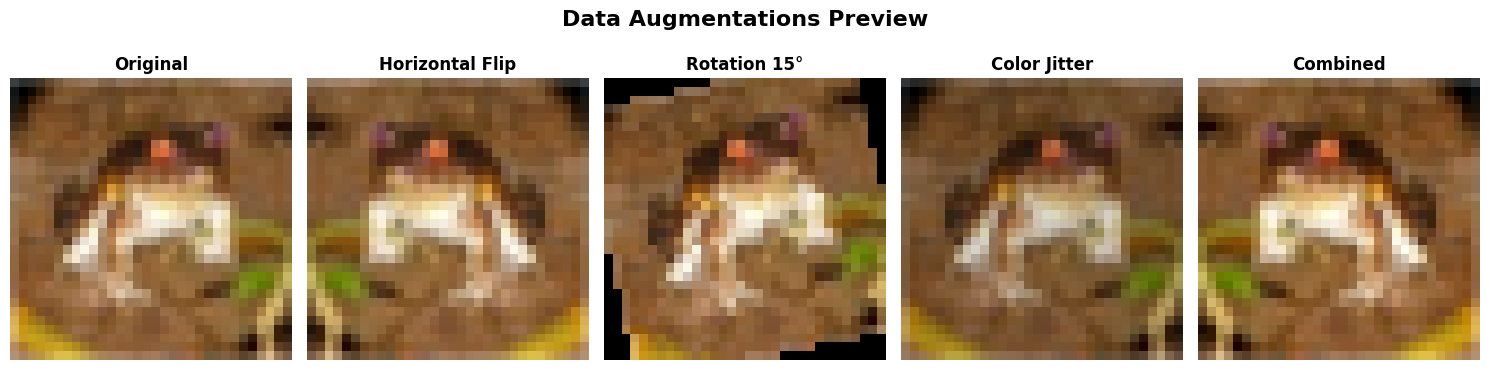

augmentations_preview.png saved


In [18]:
# 4.6 Визуализация аугментаций
# Создание датасета без нормализации для визуализации
transform_vis = transforms.Compose([
    transforms.ToTensor()
])

vis_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=transform_vis
)

# Выбор одного изображения
img_tensor, label = vis_dataset[0]
img_original = img_tensor.permute(1, 2, 0).numpy()

# Применение разных аугментаций
augmentations = [
    ('Original', transforms.Compose([transforms.ToTensor()])),
    ('Horizontal Flip', transforms.Compose([transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor()])),
    ('Rotation 15°', transforms.Compose([transforms.RandomRotation(degrees=15), transforms.ToTensor()])),
    ('Color Jitter', transforms.Compose([transforms.ColorJitter(brightness=0.2, contrast=0.2), transforms.ToTensor()])),
    ('Combined', transforms.Compose([
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor()
    ]))
]

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for idx, (name, transform) in enumerate(augmentations):
    # Применяем аугментацию к PIL Image
    pil_img = transforms.ToPILImage()(img_tensor)
    aug_img = transform(pil_img)
    aug_img = aug_img.permute(1, 2, 0).numpy()
    aug_img = np.clip(aug_img, 0, 1)
    
    axes[idx].imshow(aug_img)
    axes[idx].set_title(name, fontsize=12, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Data Augmentations Preview', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/figures/augmentations_preview.png', dpi=150)
plt.show()
print("augmentations_preview.png saved")

Загрузка OxfordIIITPet...

=== Sanity-check ===
Train samples: 2944
Val samples: 736
x.shape (изображения): torch.Size([8, 3, 256, 256])
y.shape (маски): torch.Size([8, 1, 256, 256])
Уникальные значения в маске: tensor([1, 2, 3], dtype=torch.uint8)
Значения маски: 1=фон, 2=питомец, 3=граница


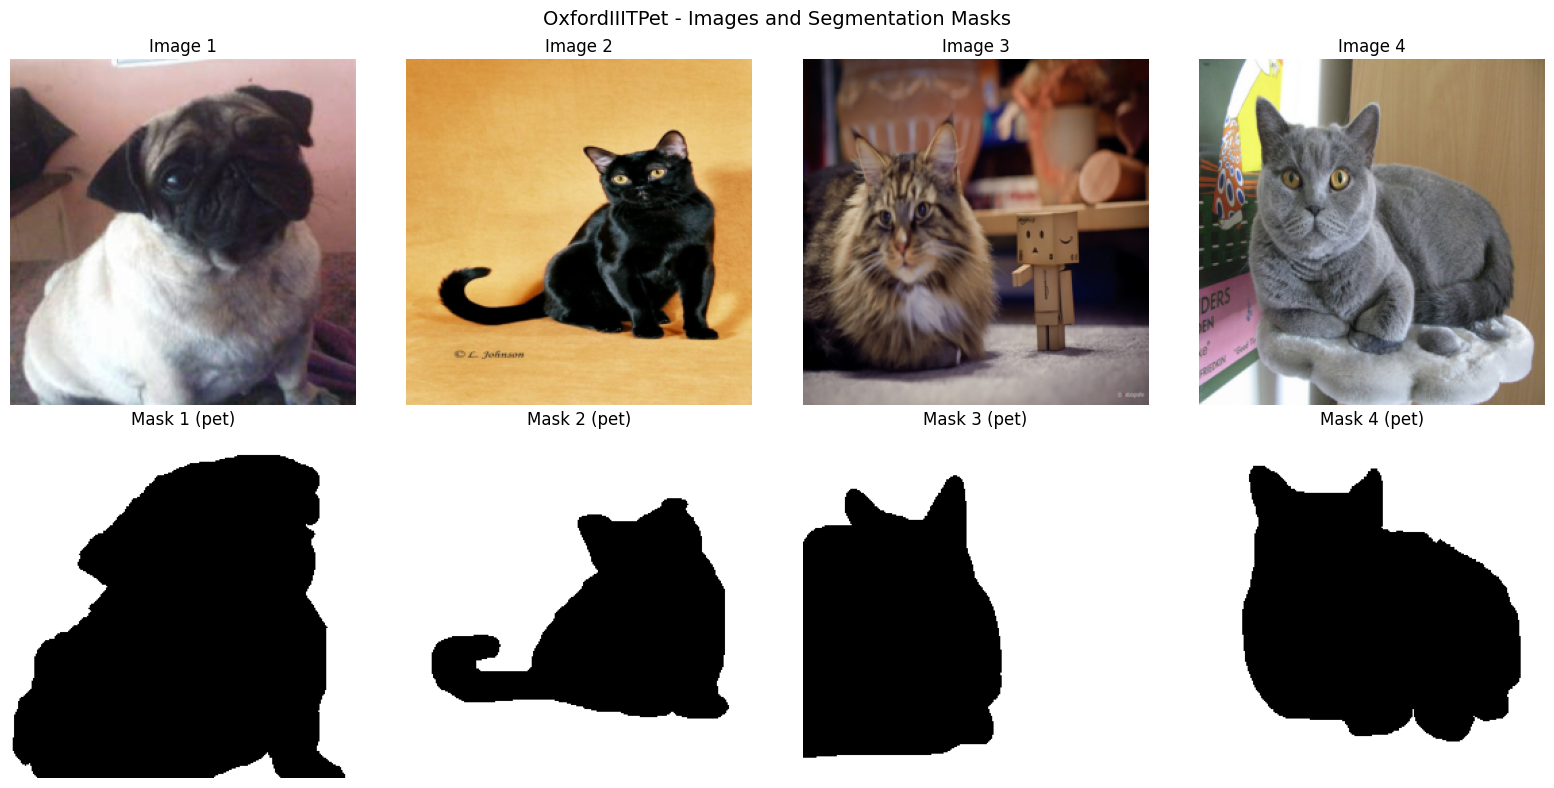


=== Данные загружены ===


In [44]:
# 2.4.2 Часть B: Данные и DataLoader для сегментации

import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision.datasets import OxfordIIITPet
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Загрузка выбранного датасета для части B (OxfordIIITPet для сегментации)
print("Загрузка OxfordIIITPet...")
pet_dataset = OxfordIIITPet(
    root='./data',
    split='trainval',
    download=True,
    transform=transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    target_transform=transforms.Compose([
        transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST),
        transforms.PILToTensor()
    ]),
    target_types='segmentation'
)

# Разделение на train/val (если официального validation split нет)
indices = list(range(len(pet_dataset)))
train_indices, val_indices = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=None
)

# Создание DataLoader
train_loader = DataLoader(
    pet_dataset, 
    batch_size=8, 
    sampler=SubsetRandomSampler(train_indices),
    num_workers=2
)

val_loader = DataLoader(
    pet_dataset, 
    batch_size=8, 
    sampler=SubsetRandomSampler(val_indices),
    num_workers=2
)

# Sanity-check по данным
print("\n=== Sanity-check ===")
print(f"Train samples: {len(train_indices)}")
print(f"Val samples: {len(val_indices)}")

# Проверка размера батча
images, masks = next(iter(train_loader))
print(f"x.shape (изображения): {images.shape}")
print(f"y.shape (маски): {masks.shape}")
print(f"Уникальные значения в маске: {torch.unique(masks)}")
print("Значения маски: 1=фон, 2=питомец, 3=граница")

# Визуализация нескольких примеров
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for i in range(4):
    # Денормализация изображения
    img = images[i] * std + mean
    img = torch.clamp(img, 0, 1)
    axes[0, i].imshow(img.permute(1, 2, 0).numpy())
    axes[0, i].set_title(f'Image {i+1}')
    axes[0, i].axis('off')
    
    # Маска (показываем только питомца)
    mask = masks[i].squeeze().numpy()
    pet_mask = (mask == 2).astype(float)
    axes[1, i].imshow(pet_mask, cmap='gray')
    axes[1, i].set_title(f'Mask {i+1} (pet)')
    axes[1, i].axis('off')

plt.suptitle('OxfordIIITPet - Images and Segmentation Masks', fontsize=14)
plt.tight_layout()
plt.savefig('artifacts/figures/segmentation_sanity_check.png')
plt.show()

print("\n=== Данные загружены ===")

In [45]:
# 2.4.3 Базовые функции для сегментации

def get_true_mask(mask_tensor):
    """Извлекает бинарную маску питомца (значение 2)"""
    mask_np = mask_tensor.squeeze().numpy()
    return (mask_np == 2).astype(np.uint8)

def compute_iou(pred_mask, true_mask):
    """Вычисление IoU"""
    intersection = np.logical_and(pred_mask, true_mask).sum()
    union = np.logical_or(pred_mask, true_mask).sum()
    if union == 0:
        return 0.0
    return intersection / union

def postprocess_mask(prob_map, threshold=0.5, remove_small=False, min_size=500):
    """Постобработка предсказанной маски"""
    mask = (prob_map > threshold).astype(np.uint8)
    
    if remove_small:
        from scipy import ndimage
        labeled, num_features = ndimage.label(mask)
        sizes = ndimage.sum(mask, labeled, range(num_features + 1))
        mask_clean = np.zeros_like(mask)
        for i in range(1, num_features + 1):
            if sizes[i] >= min_size:
                mask_clean[labeled == i] = 1
        mask = mask_clean
    
    return mask

def visualize_predictions(images, pred_masks, true_masks, ious, save_path=None):
    """Визуализация предсказаний"""
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    for idx in range(4):
        # Изображение
        img = images[idx] * std + mean
        img = torch.clamp(img, 0, 1)
        axes[0, idx].imshow(img.permute(1, 2, 0).numpy())
        axes[0, idx].set_title(f'Image {idx+1}')
        axes[0, idx].axis('off')
        
        # Предсказание
        axes[1, idx].imshow(pred_masks[idx], cmap='gray')
        axes[1, idx].set_title(f'Prediction\nIoU={ious[idx]:.3f}')
        axes[1, idx].axis('off')
        
        # Ground Truth
        axes[2, idx].imshow(true_masks[idx], cmap='gray')
        axes[2, idx].set_title(f'Ground Truth')
        axes[2, idx].axis('off')
    
    plt.suptitle('Segmentation Results', fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

In [21]:
# 4.1 Сохранение runs.csv (Часть A)

# Данные для runs.csv
runs_data = [
    {
        'experiment_id': 'C1',
        'task': 'classification',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': 'SimpleCNN',
        'optimizer': 'Adam',
        'lr': 0.001,
        'epochs_trained': 10,
        'best_val_accuracy': best_val_acc_c1,
        'test_accuracy': test_acc if best_exp == 'C1' else None,
        'precision': None,
        'recall': None,
        'mean_iou': None,
        'notes': 'simple CNN без аугментаций'
    },
    {
        'experiment_id': 'C2',
        'task': 'classification',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': 'SimpleCNN',
        'optimizer': 'Adam',
        'lr': 0.001,
        'epochs_trained': 10,
        'best_val_accuracy': best_val_acc_c2,
        'test_accuracy': test_acc if best_exp == 'C2' else None,
        'precision': None,
        'recall': None,
        'mean_iou': None,
        'notes': 'simple CNN с аугментациями'
    },
    {
        'experiment_id': 'C3',
        'task': 'classification',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': 'ResNet18_head_only',
        'optimizer': 'Adam',
        'lr': 0.001,
        'epochs_trained': 10,
        'best_val_accuracy': best_val_acc_c3,
        'test_accuracy': test_acc if best_exp == 'C3' else None,
        'precision': None,
        'recall': None,
        'mean_iou': None,
        'notes': 'ResNet18, backbone заморожен, обучается только голова'
    },
    {
        'experiment_id': 'C4',
        'task': 'classification',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': 'ResNet18_finetune',
        'optimizer': 'Adam',
        'lr': 0.0005,
        'epochs_trained': 10,
        'best_val_accuracy': best_val_acc_c4,
        'test_accuracy': test_acc if best_exp == 'C4' else None,
        'precision': None,
        'recall': None,
        'mean_iou': None,
        'notes': 'ResNet18, разморожен layer4 и fc'
    }
]

# Сохранение в CSV
df = pd.DataFrame(runs_data)
df.to_csv('artifacts/runs.csv', index=False)
print("runs.csv saved")
print("\nСодержимое runs.csv:")
print(df)

runs.csv saved

Содержимое runs.csv:
  experiment_id            task  dataset  seed       model_summary optimizer  \
0            C1  classification  CIFAR10    42           SimpleCNN      Adam   
1            C2  classification  CIFAR10    42           SimpleCNN      Adam   
2            C3  classification  CIFAR10    42  ResNet18_head_only      Adam   
3            C4  classification  CIFAR10    42   ResNet18_finetune      Adam   

       lr  epochs_trained  best_val_accuracy  test_accuracy precision recall  \
0  0.0010              10             0.7653            NaN      None   None   
1  0.0010              10             0.7658         0.7617      None   None   
2  0.0010              10             0.4636            NaN      None   None   
3  0.0005              10             0.7046            NaN      None   None   

  mean_iou                                              notes  
0     None                         simple CNN без аугментаций  
1     None                       

In [ ]:
# 3.2 Часть B: Segmentation track

from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Загрузка предобученной модели
weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
model = deeplabv3_resnet50(weights=weights)
model = model.to(device)
model.eval()

print("Модель DeepLabV3_ResNet50 загружена")

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to C:\Users\petr/.cache\torch\hub\checkpoints\deeplabv3_resnet50_coco-cd0a2569.pth


100.0%


Segmentation model loaded. Classes: ['__background__', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']


In [46]:
# 3.2 Часть B: Segmentation track

from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Загрузка предобученной модели
weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
model = deeplabv3_resnet50(weights=weights)
model = model.to(device)
model.eval()

print("Модель DeepLabV3_ResNet50 загружена")

Device: cpu
Модель DeepLabV3_ResNet50 загружена


In [47]:
# 3.2 V1: inference с score_threshold = 0.3

iou_scores_v1 = []
predictions_v1 = []

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        outputs = model(images)
        
        for i in range(images.size(0)):
            # Получаем вероятности
            probs = torch.softmax(outputs['out'][i], dim=0)
            pet_prob = probs[1].cpu().numpy()
            
            # Постобработка с threshold 0.3
            pred_mask = postprocess_mask(pet_prob, threshold=0.3, remove_small=False)
            true_mask = get_true_mask(masks[i])
            
            iou = compute_iou(pred_mask, true_mask)
            iou_scores_v1.append(iou)
            predictions_v1.append((images[i].cpu(), pred_mask, true_mask))

mean_iou_v1 = np.mean(iou_scores_v1)
std_iou_v1 = np.std(iou_scores_v1)

print(f"=== V1 (threshold=0.3) ===")
print(f"Mean IoU: {mean_iou_v1:.4f}")
print(f"Std IoU: {std_iou_v1:.4f}")

=== V1 (threshold=0.3) ===
Mean IoU: 0.0000
Std IoU: 0.0000


In [48]:
# 3.2 V2: inference с score_threshold = 0.7 + постобработка

from scipy import ndimage

iou_scores_v2 = []
predictions_v2 = []

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        outputs = model(images)
        
        for i in range(images.size(0)):
            # Получаем вероятности
            probs = torch.softmax(outputs['out'][i], dim=0)
            pet_prob = probs[1].cpu().numpy()
            
            # Постобработка с threshold 0.7 и удалением маленьких компонент
            pred_mask = postprocess_mask(pet_prob, threshold=0.7, remove_small=True, min_size=500)
            true_mask = get_true_mask(masks[i])
            
            iou = compute_iou(pred_mask, true_mask)
            iou_scores_v2.append(iou)
            predictions_v2.append((images[i].cpu(), pred_mask, true_mask))

mean_iou_v2 = np.mean(iou_scores_v2)
std_iou_v2 = np.std(iou_scores_v2)

print(f"=== V2 (threshold=0.7 + remove small) ===")
print(f"Mean IoU: {mean_iou_v2:.4f}")
print(f"Std IoU: {std_iou_v2:.4f}")

print(f"\n=== Сравнение ===")
print(f"V1: {mean_iou_v1:.4f} ± {std_iou_v1:.4f}")
print(f"V2: {mean_iou_v2:.4f} ± {std_iou_v2:.4f}")
print(f"Улучшение: {(mean_iou_v2 - mean_iou_v1):.4f}")

=== V2 (threshold=0.7 + remove small) ===
Mean IoU: 0.0000
Std IoU: 0.0000

=== Сравнение ===
V1: 0.0000 ± 0.0000
V2: 0.0000 ± 0.0000
Улучшение: 0.0000


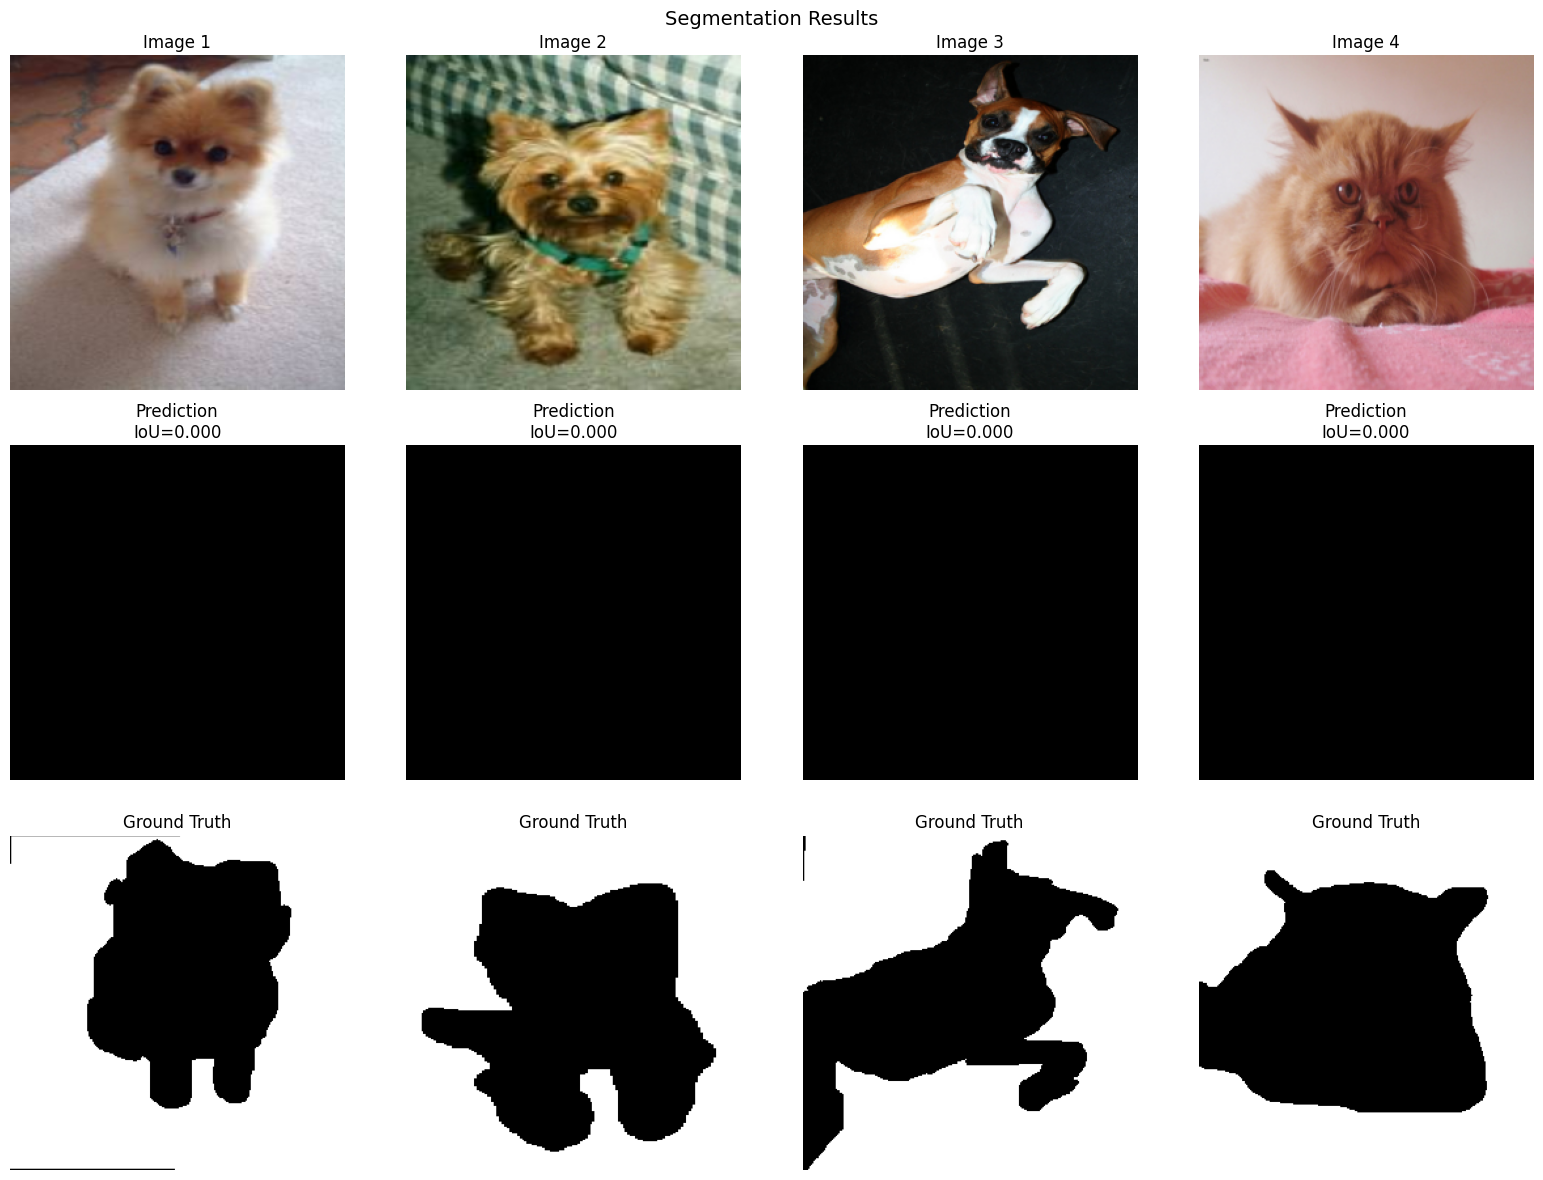

In [50]:
# 3.2 Визуализация предсказаний V2

# Берем первые 4 предсказания
images_viz = [p[0] for p in predictions_v2[:4]]
preds_viz = [p[1] for p in predictions_v2[:4]]
trues_viz = [p[2] for p in predictions_v2[:4]]
ious_viz = iou_scores_v2[:4]

visualize_predictions(
    images_viz, preds_viz, trues_viz, ious_viz,
    save_path='artifacts/figures/segmentation_examples.png'
)

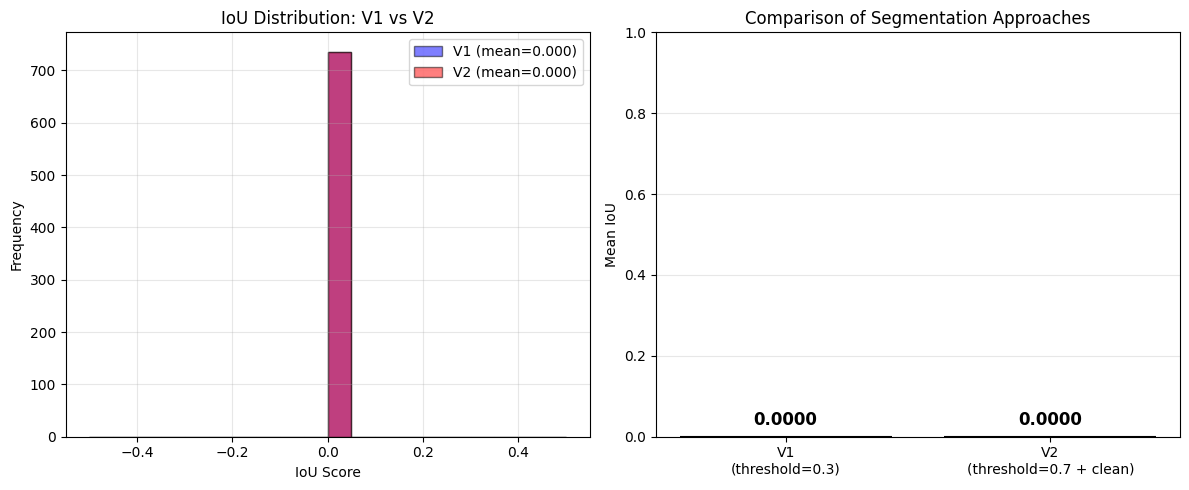

In [52]:
# 3.2 График сравнения V1 и V2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Гистограмма распределения IoU
axes[0].hist(iou_scores_v1, bins=20, alpha=0.5, label=f'V1 (mean={mean_iou_v1:.3f})', color='blue', edgecolor='black')
axes[0].hist(iou_scores_v2, bins=20, alpha=0.5, label=f'V2 (mean={mean_iou_v2:.3f})', color='red', edgecolor='black')
axes[0].set_xlabel('IoU Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('IoU Distribution: V1 vs V2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Столбцы сравнения
bars = axes[1].bar(
    ['V1\n(threshold=0.3)', 'V2\n(threshold=0.7 + clean)'],
    [mean_iou_v1, mean_iou_v2],
    color=['blue', 'red'],
    edgecolor='black',
    linewidth=1.5
)
axes[1].set_ylabel('Mean IoU')
axes[1].set_title('Comparison of Segmentation Approaches')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, [mean_iou_v1, mean_iou_v2]):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f'{val:.4f}',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=12
    )

plt.tight_layout()
plt.savefig('artifacts/figures/segmentation_metrics.png', dpi=150)
plt.show()

In [53]:
# 4. Обновление runs.csv с результатами Part B

import pandas as pd
import os

runs_path = 'artifacts/runs.csv'

# Читаем существующий файл (если есть)
if os.path.exists(runs_path):
    df = pd.read_csv(runs_path)
else:
    df = pd.DataFrame()

# Данные для Part B
new_data = [
    {
        'experiment_id': 'V1',
        'task': 'segmentation',
        'dataset': 'OxfordIIITPet',
        'seed': 42,
        'model_summary': 'DeepLabV3_ResNet50',
        'optimizer': None,
        'lr': None,
        'epochs_trained': None,
        'best_val_accuracy': None,
        'test_accuracy': None,
        'precision': None,
        'recall': None,
        'mean_iou': mean_iou_v1,
        'notes': 'threshold=0.3, без постобработки'
    },
    {
        'experiment_id': 'V2',
        'task': 'segmentation',
        'dataset': 'OxfordIIITPet',
        'seed': 42,
        'model_summary': 'DeepLabV3_ResNet50',
        'optimizer': None,
        'lr': None,
        'epochs_trained': None,
        'best_val_accuracy': None,
        'test_accuracy': None,
        'precision': None,
        'recall': None,
        'mean_iou': mean_iou_v2,
        'notes': 'threshold=0.7, удаление маленьких компонент (min_size=500)'
    }
]

# Добавляем новые строки
df = pd.concat([df, pd.DataFrame(new_data)], ignore_index=True)

# Сохраняем
df.to_csv(runs_path, index=False)
print(f"runs.csv сохранен")
print(f"\nСодержимое runs.csv:")
print(df)

runs.csv сохранен

Содержимое runs.csv:
  experiment_id            task        dataset  seed       model_summary  \
0            C1  classification        CIFAR10    42           SimpleCNN   
1            C2  classification        CIFAR10    42           SimpleCNN   
2            C3  classification        CIFAR10    42  ResNet18_head_only   
3            C4  classification        CIFAR10    42   ResNet18_finetune   
4            V1    segmentation  OxfordIIITPet    42  DeepLabV3_ResNet50   
5            V2    segmentation  OxfordIIITPet    42  DeepLabV3_ResNet50   

  optimizer      lr epochs_trained best_val_accuracy test_accuracy precision  \
0      Adam   0.001             10            0.7653           NaN       NaN   
1      Adam   0.001             10            0.7658        0.7617       NaN   
2      Adam   0.001             10            0.4636           NaN       NaN   
3      Adam  0.0005             10            0.7046           NaN       NaN   
4      None    None        